{'topic': '猫', 'joke': '一只猫追着自己的尾巴转圈，转了几十圈后晕倒在地。另一只猫路过问：“你干嘛呢？”它晕乎乎地回答：“我在练无敌风火轮，结果把自己转成陀螺了。”', 'improved_joke': '一只猫追着自己的尾巴转圈，转了几十圈后“晕”倒在地。另一只猫路过问：“你干嘛呢？”它晕乎乎地回答：“我在练无敌风火轮，结果……把自己‘转’成了‘螺旋’——这下真成‘晕’环了！”（双关：谐音“晕环”既是旋转的圆圈，又指猫被转晕的状态）', 'final_joke': '一只猫追着自己的尾巴转圈，转了几十圈后“晕”倒在地。另一只猫路过问：“你干嘛呢？”它晕乎乎地回答：“我在练无敌风火轮，结果……把自己‘转’成了‘螺旋’——这下真成‘晕’环了！”  \n话音刚落，那只路过的猫突然掏出手机，对着它说：“别动！你这个‘晕环’图案正好符合我们‘喵界晕眩挑战赛’的冠军标准——奖金五万罐小鱼干！”  \n晕在地上的猫猛地坐起来，眼睛发亮：“什么？那我要再转晕几次，凑个‘奥运五环’！”  \n另一只猫冷笑一声：“晚了——刚拍下的视频已经上热搜了，你现在的‘晕环’只能当表情包。”'}


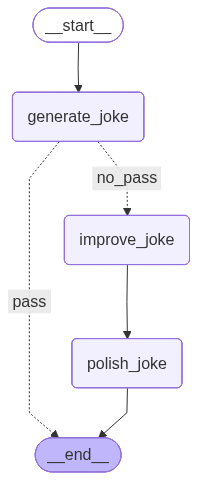

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 图状态
class OverAllState(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# 节点
def generate_joke(state: OverAllState) -> OverAllState:
    """第一次调用大模型，生成初始笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于“{state['topic']}”的简短笑话")]
    )
    return {"joke": msg.content}

def check_punchline(state: OverAllState) -> Literal["pass", "no_pass"]:
    """判断笑话中是否包含包袱"""

    # 简单判断：笑话中是否包含问号或感叹号
    if "?" in state["joke"] or "!" in state["joke"]:
        return "pass"
    return "no_pass"

def improve_joke(state: OverAllState) -> OverAllState:
    """第二次调用大模型，通过添加双关语改进笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"通过添加双关语，让下面这个笑话变得更有趣：\n{state['joke']}")]
    )
    return {"improved_joke": msg.content}

def polish_joke(state: OverAllState) -> OverAllState:
    """第三次调用大模型，对笑话进行最终润色"""

    msg = model.invoke(
        [HumanMessage(content=f"为下面这个笑话添加一个出人意料的反转：\n{state['improved_joke']}")]
    )
    return {"final_joke": msg.content}

# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("generate_joke", generate_joke)
builder.add_node("improve_joke", improve_joke)
builder.add_node("polish_joke", polish_joke)

# 添加边，连接各个节点
builder.add_edge(START, "generate_joke")
builder.add_conditional_edges(
    "generate_joke",
    check_punchline,
    {
        "no_pass": "improve_joke",
        "pass": END,
    },
)
builder.add_edge("improve_joke", "polish_joke")
builder.add_edge("polish_joke", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
response = graph.invoke({"topic": "猫"})
print(response)

# 绘制拓扑结构
from IPython.display import display
display(graph)